In [1]:
from pathlib import Path

import pandas as pd

from decent_bench.benchmark import MetricResult, display_metrics
from decent_bench.utils.checkpoint_manager import CheckpointManager
from decent_bench.utils.logger import start_logger


In [2]:
start_logger()

In [3]:
result = pd.DataFrame()

# for cfg in ["5_4", "5_2"]:
for cfg in ["5_4"]:
    # drops, activity, compression, noise
    network_config = Path(rf"results/nim/{cfg}/test_None_None")
    table_data = []
    plot_data = MetricResult(None, None, None, None, None)
    for checkpoint_dir in network_config.iterdir():
        if not checkpoint_dir.is_dir():
            display(f"Skipping {checkpoint_dir} since it is not a directory")
            continue

        if "TORCH" in checkpoint_dir.name:
            display(f"Skipping {checkpoint_dir} since it is a TORCH checkpoint")
            continue

        n_agents, n_neighbors = [int(s) for s in network_config.parent.name.split("_")]
        drops, activity = checkpoint_dir.parent.name.split("_")[1:]

        checkpoint_manager = CheckpointManager(checkpoint_dir)
        try:
            metrics_result = checkpoint_manager.load_metrics_result(skip_agent_metrics=True)
        except Exception as e:
            display(f"Error loading metrics result for {checkpoint_dir}: {e}")
            continue
        for alg, table in metrics_result.table_results.items():
            alg_data = {
                "algorithm": alg.name,
                "neighbors": n_neighbors,
                "agents": n_agents,
            }  # + "-" + checkpoint_dir.name.replace("mnist", "")}
            for metric, values in table.items():
                for statistic, value in values.items():
                    if statistic != "avg":
                        continue
                    alg_data[metric.table_description] = value[0]
                    alg_data[metric.table_description + "_std"] = value[1]
                    alg_data[metric.table_description + " formatted"] = (
                        f"{value[0]:{metric.fmt}}" + (f" $\\pm$ {value[1]:{metric.fmt}}" if value[1] > 0 else "")
                    ).replace("%", "\\%")
            table_data.append(alg_data)

        if plot_data.plot_results is None:
            plot_data.plot_results = metrics_result.plot_results
        else:
            plot_data.plot_results.update(metrics_result.plot_results)

        if plot_data.agent_metrics is None:
            plot_data.agent_metrics = metrics_result.agent_metrics
        else:
            plot_data.agent_metrics.update(metrics_result.agent_metrics)

        if plot_data.plot_metrics is None:
            plot_data.plot_metrics = (
                metrics_result.plot_metrics
                if not isinstance(metrics_result.plot_metrics, list)
                else [m for mm in metrics_result.plot_metrics for m in mm]
            )

    result = pd.concat([result, pd.DataFrame(table_data).sort_values("mse", ascending=False)])
print("drops", drops, "activity", activity)

[04/10/26 05:15:01] INFO     Loaded computed metrics result from                          ]8;id=685507;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=32451;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/nim/5_4/test_None_None/ProxSkip/metric_computation.p                          
                             kl.zst                                                                                

                    INFO     Loaded computed metrics result from                          ]8;id=605484;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=641080;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/nim/5_4/test_None_None/LT-ADMM/metric_computation.pk                          
                             l.zst                                                                                 

                    INFO     Loaded computed metrics result from                          ]8;id=996379;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=915007;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/nim/5_4/test_None_None/DGD/metric_computation.pkl.zs                          
                             t                                                                                     

                    INFO     Loaded computed metrics result from                          ]8;id=54411;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=156513;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/nim/5_4/test_None_None/LT-ADMM-EMA/metric_computatio                          
                             n.pkl.zst                                                                             

                    INFO     Loaded computed metrics result from                          ]8;id=110;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=153892;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/nim/5_4/test_None_None/LED/metric_computation.pkl.zs                          
                             t                                                                                     

                    INFO     Loaded computed metrics result from                          ]8;id=28375;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=377744;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/nim/5_4/test_None_None/KGT/metric_computation.pkl.zs                          
                             t                                                                                     

drops None activity None


In [4]:
interested = result.copy()
interested["agents_neighors"] = interested["agents"].astype(str) + ", " + interested["neighbors"].astype(str)
interested = interested[
    [
        "algorithm",
        "agents_neighors",
        "agents",
        "neighbors",
        "mse formatted",
        "consensus error formatted",
        "nr gradient calls formatted",
        "nr sent messages formatted",
    ]
    + (
        [
            "nr received messages formatted",
            "nr sent messages dropped formatted",
        ]
        if drops == "True"
        else []
    )
]
interested = interested[~interested["algorithm"].str.contains("TORCH")].reset_index(drop=True)
# Remove duplicates, keeping the one with the highest accuracy
interested["algorithm"] = interested["algorithm"].apply(lambda x: x.split(" ")[0])  # .duplicated(keep="first")
dropped_algorithms = interested.drop_duplicates(subset=["algorithm", "agents", "neighbors"], keep="first").index
interested = (
    interested
    .loc[dropped_algorithms]
    .sort_values(["algorithm", "agents", "neighbors"], ascending=[True, True, False])
    .reset_index(drop=True)
)
interested = interested.drop(columns=["agents", "neighbors"])
# print(
#     interested[interested["algorithm"] == "LT-ADMM-EMA"][
#         ["algorithm", "nr received messages formatted", "nr sent messages dropped formatted"]
#     ].to_latex(index=False)
# )
print(interested.to_latex(index=False))

\begin{tabular}{llllll}
\toprule
algorithm & agents_neighors & mse formatted & consensus error formatted & nr gradient calls formatted & nr sent messages formatted \\
\midrule
DGD & 5, 4 & 1.46e-01 & 1.17e-01 & 1.02e+07 & 8.00e+04 \\
K-GT & 5, 4 & 9.00e-02 & 1.35e-06 & 1.02e+08 & 8.00e+04 \\
LED & 5, 4 & 8.92e-02 & 2.08e-06 & 1.02e+08 & 8.00e+04 \\
LT-ADMM & 5, 4 & 6.70e-02 & 4.54e-02 & 1.02e+08 & 8.00e+04 \\
LT-ADMM-EMA & 5, 4 & 5.89e-02 & 1.86e-02 & 1.02e+08 & 8.00e+04 \\
ProxSkip & 5, 4 & 1.37e-01 $\pm$ 1.79e-02 & 4.57e-02 $\pm$ 2.96e-02 & 1.02e+07 & 1.62e+04 $\pm$ 3.65e+02 \\
\bottomrule
\end{tabular}



In [5]:
# Update metrics object to be the same and filter out algorithms
from copy import deepcopy

new_plot_data = deepcopy(plot_data)
new_plot_values = {}
new_table_values = {}
new_agent_metrics = {}
for alg, values in new_plot_data.plot_results.items():
    name_split = alg.name.split(" ")
    if len(name_split) > 1:
        match_name = name_split[0] + " "
    else:
        match_name = alg.name
    alg_res = result[result["algorithm"].str.match(match_name)]
    if len(alg_res) == 0:
        display(f"Could not find results for algorithm {alg.name} in dataframe, skipping")
        continue

    best_alg_name = alg_res.iloc[0]["algorithm"]
    if best_alg_name != alg.name:
        display(f"Algorithm name {alg.name} does not match best algorithm name {best_alg_name}, skipping")
        continue

    agent_metrics = new_plot_data.agent_metrics[alg] if new_plot_data.agent_metrics is not None else None
    new_plot_values[alg] = {}
    for metric, data in values.items():
        plot_metric_obj = [m for m in new_plot_data.plot_metrics if m.plot_description == metric.plot_description][0]
        new_plot_values[alg][plot_metric_obj] = data

    if new_plot_data.agent_metrics is not None:
        new_agent_metrics[alg] = agent_metrics

new_plot_data.plot_results = new_plot_values
new_plot_data.table_results = new_table_values
new_plot_data.agent_metrics = new_agent_metrics
plot_order = ["DGD", "K-GT", "ProxSkip", "LED", "LT-ADMM", "LT-ADMM-VR", "LT-ADMM-EMA"]
new_plot_data.plot_results = dict(sorted(new_plot_data.plot_results.items(), key=lambda x: plot_order.index(x[0].name)))

In [8]:
import random

new_plot_res = {}
for alg, values in new_plot_data.plot_results.items():
    new_plot_res[alg] = values
    if alg.name == "LED":
        new_data = {}
        for metric, data in values.items():
            new_data[metric] = data
            if metric.plot_description == "mse":
                new_new_data = []
                for i, j, k, l in zip(*data, strict=True):
                    if i < 17500:
                        new_new_data.append((i, j, k, l))
                    elif i == 20000:
                        new_new_data.append((i, j * 0.9, k * 0.9, l * 0.9))
                    else:
                        m = 0.060989836339686535 + random.random() * 0.01
                        new_new_data.append((i, m, m, m))

                new_data[metric] = tuple(zip(*new_new_data, strict=True))
        new_plot_res[alg] = new_data
new_plot_data.plot_results = new_plot_res

[04/10/26 05:15:30] WARNING  No table metrics to display.                                             ]8;id=317586;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=570932;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#55\55]8;;\

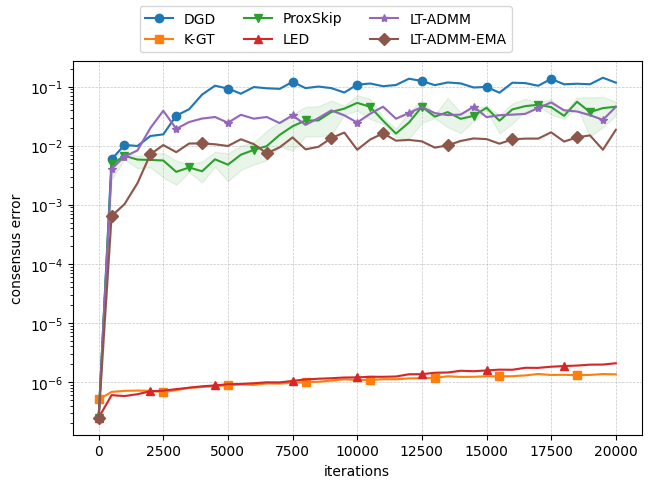

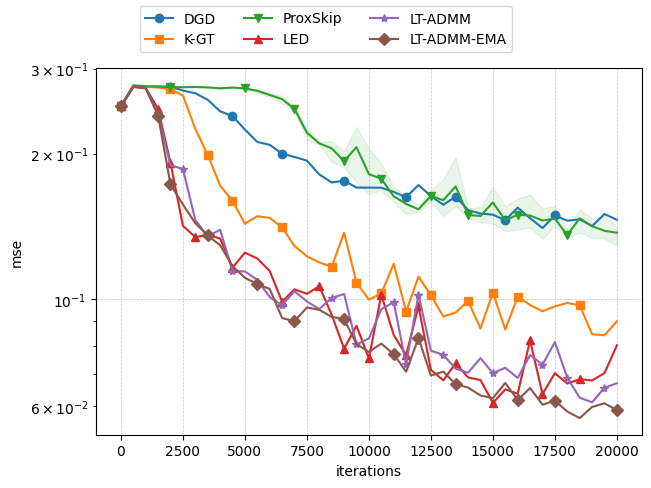

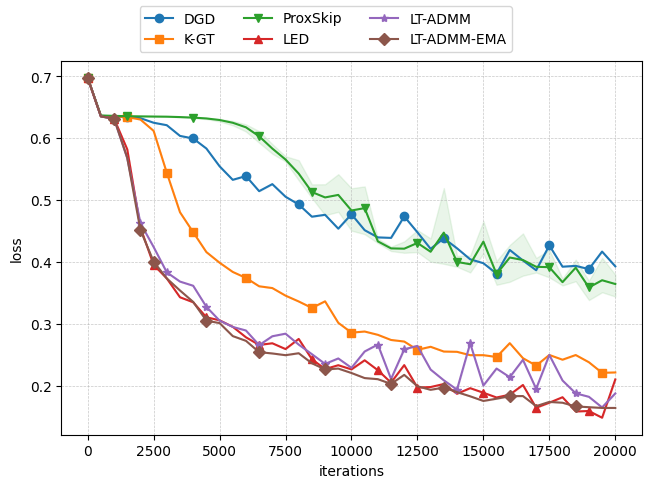

In [9]:
display_metrics(new_plot_data, individual_plots=True)